In [12]:
import pandas as pd 
from matplotlib import pyplot as plt
import numpy as np

In [2]:
# import the datasets 
df = pd.read_csv("car_prices.csv")
df.head()

,car_id,mileage,selling_price
0,A001,126958,9734
1,A002,151867,8775
2,A003,136932,3928
3,A004,108694,12454
4,A005,124879,6634


In [3]:
df.shape

(300, 3)

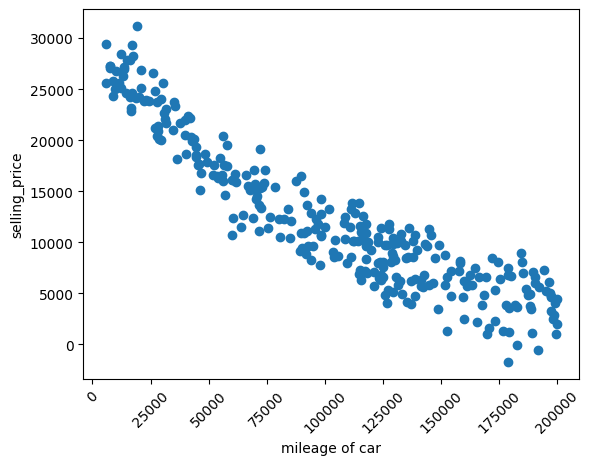

In [4]:
plt.scatter(df.mileage , df.selling_price) 
plt.xlabel("mileage of car")
plt.ylabel("selling_price")
plt.xticks(rotation=45)
plt.show() 

In [5]:
df.head(5)

,car_id,mileage,selling_price
0,A001,126958,9734
1,A002,151867,8775
2,A003,136932,3928
3,A004,108694,12454
4,A005,124879,6634


In [6]:
# seprate the dependent and independent variable 
x = df[["mileage"]]
y = df["selling_price"]
 

In [7]:
# now using train test split method to train the data 
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split( x , y , test_size = 0.20 )
x_test.head()

,mileage
43,71803
100,184262
89,43044
118,57256
239,98384


In [8]:
# now its to train the model with use of polynomial regression 
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.fit_transform(x_test)


In [9]:
# now we usedlinaer regression model to train the data 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , r2_score
model = LinearRegression()
model.fit(x_train_poly , y_train )

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
y_predict = model.predict(x_test_poly)
mse = mean_squared_error(y_test , y_predict)
r2 = r2_score(y_test , y_predict)
mse , r2

(4298386.399324787, 0.9221275073503079)

In [17]:
x_range = np.linspace(x["mileage"].min() , x["mileage"].max() , 300).reshape(-1, 1)
x_range_poly = poly.fit_transform(x_range)
y_range_pred = model.predict(x_range_poly)


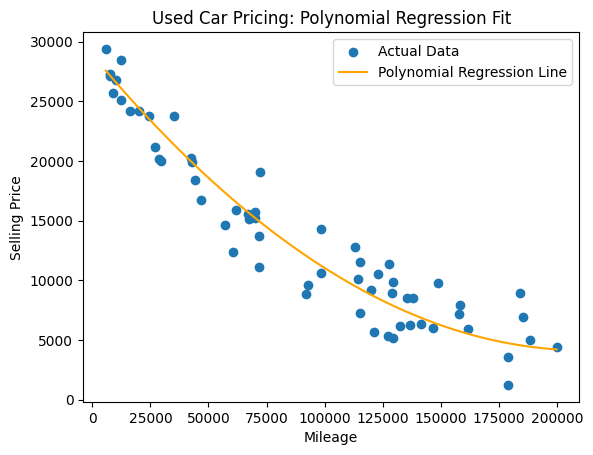

In [21]:
plt.scatter(x_test['mileage'], y_test, label='Actual Data')
plt.plot(x_range, y_range_pred, color='orange', label='Polynomial Regression Line')
plt.title('Used Car Pricing: Polynomial Regression Fit')
plt.xlabel('Mileage')
plt.ylabel('Selling Price')
plt.legend()
plt.show()